In [3]:
import pandas as pd

# Load all CSVs
airlines = pd.read_csv("../datasets/airlines.csv")
airports = pd.read_csv("../datasets/airports.csv")
flights = pd.read_csv("../datasets/flights.csv")

# Check shape of each file
print("Airlines:", airlines.shape)
print("Airports:", airports.shape)
print("Flights:", flights.shape)

# Preview first 5 rows
display(airlines.head())
display(airports.head())
display(flights.head())

/tmp/ipykernel_304940/1127109869.py:6: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv("../datasets/flights.csv")


Airlines: (14, 2)
Airports: (322, 7)
Flights: (5819079, 31)


,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


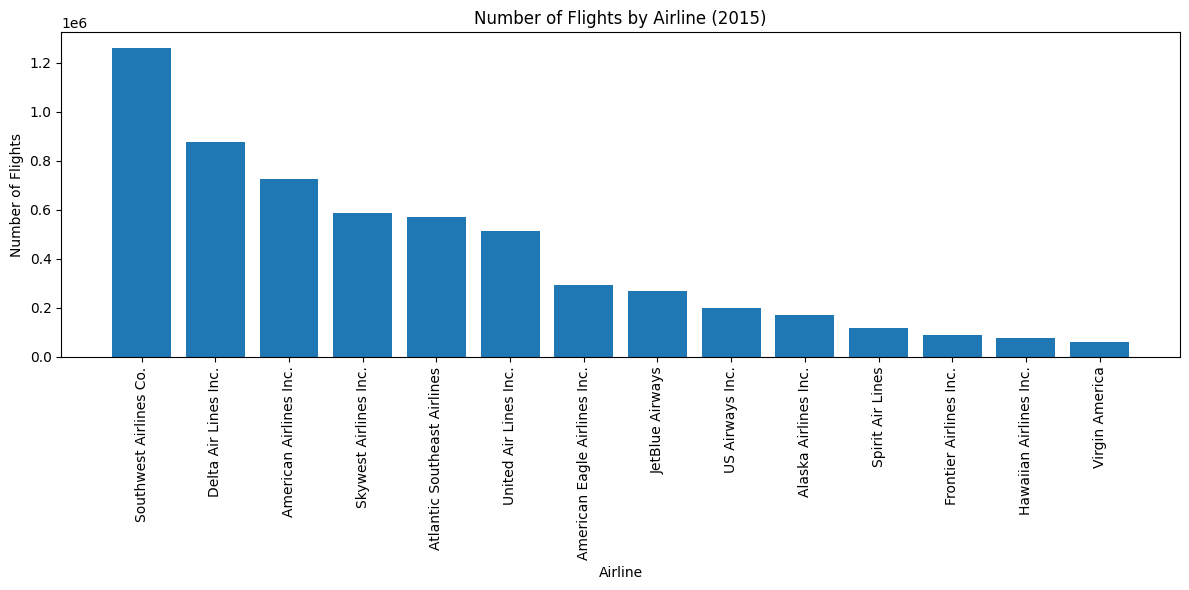

In [4]:
# Step 1: Count number of flights per airline code
airline_flight_counts = flights.groupby("AIRLINE").size().reset_index(name="flight_count")

# Step 2: Merge with airline names
airline_flight_counts = airline_flight_counts.merge(airlines, left_on="AIRLINE", right_on="IATA_CODE")

# Step 3: Drop code columns and keep only readable ones
airline_flight_counts = airline_flight_counts[["AIRLINE_y", "flight_count"]]
airline_flight_counts.rename(columns={"AIRLINE_y": "Airline"}, inplace=True)

# Step 4: Sort descending
airline_flight_counts = airline_flight_counts.sort_values(by="flight_count", ascending=False)

# Step 5: Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(airline_flight_counts["Airline"], airline_flight_counts["flight_count"])
plt.xticks(rotation=90)
plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.title("Number of Flights by Airline (2015)")
plt.tight_layout()
plt.show()


In [5]:
# How many nulls in each column?
nulls = flights.isnull().sum()
nulls[nulls > 0].sort_values(ascending=False)


CANCELLATION_REASON    5729195
SECURITY_DELAY         4755640
AIR_SYSTEM_DELAY       4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
AIRLINE_DELAY          4755640
ARRIVAL_DELAY           105071
ELAPSED_TIME            105071
AIR_TIME                105071
TAXI_IN                  92513
WHEELS_ON                92513
ARRIVAL_TIME             92513
TAXI_OUT                 89047
WHEELS_OFF               89047
DEPARTURE_DELAY          86153
DEPARTURE_TIME           86153
TAIL_NUMBER              14721
SCHEDULED_TIME               6
dtype: int64

In [6]:
flights["FLIGHT_DATE"] = pd.to_datetime(flights[["YEAR", "MONTH", "DAY"]])


In [7]:
display(flights.head())

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,FLIGHT_DATE
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-01
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-01
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-01
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-01
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-01


In [8]:
delay_cols = ["ARRIVAL_DELAY", "AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY", "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY"]
flights[delay_cols].isnull().mean() * 100  # % of missing values


ARRIVAL_DELAY           1.805629
AIR_SYSTEM_DELAY       81.724960
SECURITY_DELAY         81.724960
AIRLINE_DELAY          81.724960
LATE_AIRCRAFT_DELAY    81.724960
WEATHER_DELAY          81.724960
dtype: float64

In [ ]:
# Sample 100,000 rows randomly for testing
flights_sample = flights.sample(n=100_000, random_state=42)

# Save to CSV (optional)
flights_sample.to_csv("../datasets/flights_sample.csv", index=False)


In [10]:
flights_sample.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,FLIGHT_DATE
1508570,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,...,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-04-07
363270,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,...,-12.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-24
3003945,2015,7,8,3,WN,1483,N463WN,OAK,SEA,630,...,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-07-08
2291425,2015,5,26,2,WN,193,N7745A,STL,DAL,810,...,152.0,0,0,NaN,0.0,0.0,0.0,152.0,0.0,2015-05-26
2973084,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,...,-2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-07-06
